# Adversarial Combined-Arms Monte Carlo (v2)
**MAJ Jon Day** · stochastic company-team attack vs. an AT-heavy defense, with random-utility target selection, CRN, and interval estimates on every output.

<!-- After saving to GitHub, replace USER/REPO below -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/USER/REPO/blob/main/adversarial_combined_arms_mc.ipynb)

## Model card
| Element | Representation |
|---|---|
| Blue | 4 tanks, 6 mech-inf teams (mounted until dismount line), 2 scout teams (if recon), supporting battery (if fires) |
| Red | 4 ATGM teams (4 missiles each), 6 infantry teams with RPG/MG, in prepared positions |
| Blue COA factors | Armor role ∈ {SBF, Maneuver, Unsupported} × Recon ∈ {0,1} × Fires ∈ {0,1} → 12 COAs |
| Red COA | Fire discipline ∈ {Early, Late (hold until trigger range or ambush sprung)} |
| Terrain | Open vs. Urban: LOS decay length, standoff distances, exposure, sharing radius, danger-close |
| Target selection | Multinomial logit over detected, in-range targets + hold fire; utility = log(perceived P_H·P_K|H·value) + threat |
| Hit probability | Circular-normal aim error; dispersion grows with range, shooter motion, target motion, suppression; × exposed-area fraction × P(LOS) |
| Detection | Per-tick hazard: sensor × signature × exposure × (1 + motion + firing) × LOS × range²; persistent; shared via scout network or local radius |
| Synergy mechanisms | Recon expands shooters' choice sets and speeds fire missions; fires suppress (↑dispersion, ↓λ, ↑hold-fire, ↓exposure) subject to danger close; SBF armor fights hull-down from standoff |
| Termination | Stochastic breakpoints (Beta); simultaneous break scored as Blue failure; timeout = Blue failure |

**Abstractions to know before trusting a number:** units are teams (one kill = combat-ineffective); shared detections act as cueing (the shooter still uses its own geometry); dismounted IFVs leave the fight; no Red counter-battery, smoke, obstacles, or C2 degradation; parameters are illustrative, **not calibrated**. Every CI below covers Monte Carlo error only — Section 9 shows why that is the smaller problem.

In [1]:
import itertools, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, chisquare
from scipy.optimize import linprog
pd.set_option("display.width", 160)

## 1. Parameters
Everything tunable lives here. Type-indexed vectors use the ids `TANK, IFV, INF, SCOUT, R_AT, R_INF`. `PK[s, t]` and `RMAX[s, t]` are shooter-row × target-column.

In [2]:
# ---------------------------------------------------------------- unit types
TANK, IFV, INF, SCOUT, R_AT, R_INF = range(6)
TYPE_NAMES = ["Tank", "IFV (mounted inf)", "Inf team", "Scout", "Red AT team", "Red inf team"]

def default_params():
    P = dict(
        # per-type vectors, indexed by type id
        area      = np.array([6.0, 6.0, 1.0, 1.0, 1.0, 1.0]),            # m^2 presented at full exposure
        theta0    = np.array([3e-4, 8e-4, 2e-3, 2e-3, 4e-4, 2e-3]),      # rad, stationary aim dispersion
        theta_s   = np.array([5e-4, 1e-3, 4e-3, 4e-3, 4e-3, 4e-3]),      # rad, added when SHOOTER moves
        theta_t   = np.array([1e-3, 1e-3, 1e-3, 1e-3, 3e-4, 1e-3]),      # rad, lead error when TARGET moves
        sensor    = np.array([0.5, 0.4, 0.8, 2.0, 0.8, 0.6]),
        signature = np.array([1.0, 1.0, 0.5, 0.2, 0.3, 0.3]),
        fire_rate = np.array([0.6, 0.6, 0.8, 0.5, 0.3, 0.8]),            # P(ready to fire) per tick
        p_supp    = np.array([0.4, 0.4, 0.3, 0.1, 0.1, 0.3]),            # shooter suppressiveness
        supp_vuln = np.array([0.1, 0.1, 1.0, 1.0, 1.0, 1.0]),            # target susceptibility
        value     = np.array([1.0, 0.9, 0.5, 0.4, 1.0, 0.6]),            # target value to the shooter
        speed     = np.array([75., 75., 20., 15., 0., 0.]),              # m per tick (tick = 15 s)
        ammo      = np.array([np.inf, np.inf, np.inf, np.inf, 4, np.inf]),# basic load (ATGMs are scarce)
        # choice model
        lam_blue=4.0, lam_red=3.0, lam_supp=0.3,     # rationality; multiplier when suppressed
        v0=np.log(0.01), dv0_supp=3.0, b_threat=1.0, # hold-fire utility, suppression bump, threat weight
        # dispersion / detection modifiers
        kappa_supp=3.0, mu_move=1.0, phi_fire=5.0, k_det=1.0,
        supp_ticks_direct=2, supp_ticks_fires=4,
        # fires
        p_mission_recon=0.5, p_mission_norecon=0.2, fires_supp=0.85,
        # breakpoints ~ Beta
        bp_blue=(8, 12), bp_red=(11, 9),
        urban_at_mult=1.6, urban_vehicle_sensor=0.4,
    )
    PK = np.zeros((6, 6)); RMAX = np.zeros((6, 6))
    for s, pk_at, pk_inf, r in [(TANK, .7, .6, 2500), (IFV, .6, .6, 1500),
                                 (INF, .5, .5, 500), (SCOUT, .4, .4, 400)]:
        PK[s, R_AT], PK[s, R_INF] = pk_at, pk_inf
        RMAX[s, [R_AT, R_INF]] = r
    PK[R_AT, [TANK, IFV, INF, SCOUT]] = [.6, .8, .05, .05]; RMAX[R_AT, :4] = 2500   # ATGM
    PK[R_INF, [TANK, IFV]] = [.2, .35];  RMAX[R_INF, [TANK, IFV]] = 300            # RPG
    PK[R_INF, [INF, SCOUT]] = [.5, .5];  RMAX[R_INF, [INF, SCOUT]] = 500           # small arms / MG
    P["PK"], P["RMAX"] = PK, RMAX
    return P

TERRAIN = {
    "open":  dict(L_los=3000, start=3000, sbf=1800, scout_op=2000, dismount=600,
                  vis_red=0.35, vis_move=1.0, vis_inf=0.6, vis_hull=0.4, vis_scout=0.3,
                  share_r=500, danger_close=300, T=220, urban=False, fires_kill=0.10, red_trigger=1500),
    "urban": dict(L_los=150, start=1200, sbf=250, scout_op=400, dismount=350,
                  vis_red=0.20, vis_move=0.8, vis_inf=0.4, vis_hull=0.3, vis_scout=0.2,
                  share_r=100, danger_close=200, T=160, urban=True, fires_kill=0.04, red_trigger=150),
}

# roster: fixed shapes for every COA so common random numbers stay synchronized
BTYPE = np.array([TANK] * 4 + [INF] * 6 + [SCOUT] * 2)
RTYPE = np.array([R_AT] * 4 + [R_INF] * 6)
BY = np.array([-150, -50, 50, 150, -250, -150, -50, 50, 150, 250, -100, 100], float)
RX = np.array([220, 150, 150, 220, 60, 20, 0, 0, 20, 60], float)
RY = np.array([-200, -80, 80, 200, -250, -150, -50, 50, 150, 250], float)
NB, NR = len(BTYPE), len(RTYPE)
IS_TANK, IS_INF, IS_SCOUT = BTYPE == TANK, BTYPE == INF, BTYPE == SCOUT


## 2. Engine
**Target selection.** Shooter $i$ picks $\arg\max_j \{\lambda V_{ij} + \varepsilon_{ij}\}$ over detected, in-range targets plus hold fire ($j=0$), with $\varepsilon\sim$ Gumbel, which yields
$P(i\to j)=e^{\lambda V_{ij}}/\sum_{j'} e^{\lambda V_{ij'}}$ and
$V_{ij}=\log(\hat P_{H,ij} P_{K|H} w_j)+\beta_T\,\mathbb 1[j \text{ engaged } i]$.

**Hit probability.** $\sigma^2_{ij}=d^2(\theta_0^2+\theta_s^2 m_i+\theta_t^2 m_j)(1+\kappa s_i)$, and
$P_H = e^{-d/L}\left[1-\exp\!\left(-\frac{v_j A_j}{2\pi\sigma^2_{ij}}\right)\right]$, which is exact for a circular target centered on the aim point.

**CRN.** Every COA uses the same roster shape (absent units start dead), and all uniforms are drawn in a fixed order and shape. Blue COAs are therefore paired within each (terrain, Red COA) column.

In [3]:
def gumbel_choice(V, V0, lam, u):
    """Multinomial-logit choice via Gumbel-max. V: (..., K) utilities (-inf = unavailable),
    V0: (...) hold-fire utility, lam: (...) rationality, u: (..., K+1) uniforms.
    Returns index in [-1, K-1]; -1 = hold fire."""
    Vall = np.concatenate([V0[..., None], V], axis=-1)
    G = -np.log(-np.log(np.clip(u, 1e-12, 1 - 1e-12)))
    return np.argmax(lam[..., None] * Vall + G, axis=-1) - 1


def hit_prob(D, vis, area, theta0, theta_s, theta_t, m_shooter, m_target, supp, kappa, L):
    """Circular-normal aim error vs. circular-equivalent exposed area, times P(LOS)."""
    sig2 = D**2 * (theta0**2 + theta_s**2 * m_shooter + theta_t**2 * m_target) * (1 + kappa * supp)
    return np.exp(-D / L) * (1 - np.exp(-vis * area / (2 * np.pi * np.maximum(sig2, 1e-9))))


def simulate(terrain, armor, recon, fires, red_coa, n, seed, P=None):
    """armor in {'SBF','Maneuver','Unsupported'}; red_coa in {'Early','Late'}.
    Returns dict of per-replication arrays."""
    P = P or default_params()
    T = TERRAIN[terrain]
    rng = np.random.default_rng(seed)
    PK, RMAX = P["PK"].copy(), P["RMAX"]
    if T["urban"]:
        for s in (R_AT, R_INF):
            PK[s, [TANK, IFV]] = np.minimum(PK[s, [TANK, IFV]] * P["urban_at_mult"], 0.95)

    b_alive = np.ones((n, NB), bool)
    if armor == "Unsupported": b_alive[:, IS_INF] = False
    if not recon:              b_alive[:, IS_SCOUT] = False
    denom = (b_alive & ~IS_SCOUT).sum(1)
    r_alive = np.ones((n, NR), bool)
    bx = np.full((n, NB), float(T["start"]))
    mounted = np.tile(IS_INF, (n, 1))
    supp_b = np.zeros((n, NB), int); supp_r = np.zeros((n, NR), int)
    fired_b = np.zeros((n, NB), bool); fired_r = np.zeros((n, NR), bool)
    last_b = np.full((n, NB), -1); last_r = np.full((n, NR), -1)
    det_b = np.zeros((n, NB, NR), bool); det_r = np.zeros((n, NR, NB), bool)
    sprung = np.zeros(n, bool)
    ammo_r = np.tile(P["ammo"][RTYPE], (n, 1))
    bp_b = rng.beta(*P["bp_blue"], n); bp_r = rng.beta(*P["bp_red"], n)
    done = np.zeros(n, bool); win = np.zeros(n, bool); t_end = np.full(n, T["T"])
    ar_b, ar_r = np.arange(NB), np.arange(NR)
    L = T["L_los"]

    for t in range(T["T"]):
        # fixed-shape draws, same order every COA -> CRN
        u = dict(db=rng.random((n, NB, NR)), dr=rng.random((n, NR, NB)),
                 gb=rng.random((n, NB, NR + 1)), gr=rng.random((n, NR, NB + 1)),
                 rb=rng.random((n, NB)), rr=rng.random((n, NR)),
                 hb=rng.random((n, NB)), hr=rng.random((n, NR)),
                 kb=rng.random((n, NB)), kr=rng.random((n, NR)),
                 sb=rng.random((n, NB)), sr=rng.random((n, NR)),
                 m=rng.random(n), ft=rng.random((n, NR)), fk=rng.random(n), fs=rng.random(n))
        live = ~done
        etype = np.where(mounted, IFV, BTYPE)                  # (n, NB) effective Blue type

        # ---- movement intent
        inf_alive = b_alive & IS_INF
        lead_inf = np.where(inf_alive, bx, np.inf).min(1)
        tank_stop = np.full(n, T["sbf"] if armor == "SBF" else 50.0)
        if armor == "Maneuver":
            tank_stop = np.where(np.isfinite(lead_inf), np.maximum(50.0, lead_inf), 50.0)
        stop = np.where(IS_TANK, tank_stop[:, None], np.where(IS_SCOUT, T["scout_op"], 30.0))
        speed = P["speed"][etype].copy()
        if armor == "Maneuver":
            any_dis = (inf_alive & ~mounted).any(1)
            speed[:, IS_TANK] = np.where(any_dis, P["speed"][INF], P["speed"][TANK])[:, None]
        moving = b_alive & (bx > stop) & (supp_b == 0)

        # ---- exposure
        vehicle = (etype == TANK) | (etype == IFV)
        vis_b = np.where(vehicle, np.where(moving, T["vis_move"], T["vis_hull"]),
                         np.where(IS_SCOUT, T["vis_scout"], T["vis_inf"]))
        vis_b = vis_b * np.where(supp_b > 0, 0.5, 1.0)
        vis_r = T["vis_red"] * np.where(supp_r > 0, 0.5, 1.0) * np.ones((n, NR))

        D = np.sqrt((bx[:, :, None] - RX) ** 2 + (BY[None, :, None] - RY) ** 2)   # (n, NB, NR)
        Dt = D.transpose(0, 2, 1)
        LOS = np.exp(-D / L)
        rng_fac = (1000.0 / np.maximum(D, 50.0)) ** 2

        # ---- detection
        sens_b = P["sensor"][etype] * np.where(T["urban"] & vehicle, P["urban_vehicle_sensor"], 1.0)
        rate_b = (sens_b[:, :, None] * P["signature"][RTYPE] * vis_r[:, None, :]
                  * (1 + P["phi_fire"] * fired_r)[:, None, :] * LOS * rng_fac * P["k_det"])
        det_b |= (u["db"] < 1 - np.exp(-rate_b)) & b_alive[:, :, None]
        det_b &= b_alive[:, :, None] & r_alive[:, None, :]
        rate_r = (P["sensor"][RTYPE][None, :, None] * P["signature"][etype][:, None, :]
                  * vis_b[:, None, :] * (1 + P["mu_move"] * moving + P["phi_fire"] * fired_b)[:, None, :]
                  * LOS.transpose(0, 2, 1) * rng_fac.transpose(0, 2, 1) * P["k_det"])
        det_r |= (u["dr"] < 1 - np.exp(-rate_r)) & r_alive[:, :, None]
        det_r &= r_alive[:, :, None] & b_alive[:, None, :]

        # ---- information sharing
        net_up = recon & (b_alive & IS_SCOUT).any(1)
        pos = np.stack([bx, np.broadcast_to(BY, bx.shape)], -1)
        S = (np.linalg.norm(pos[:, :, None] - pos[:, None, :], axis=-1) <= T["share_r"])
        S &= b_alive[:, :, None] & b_alive[:, None, :]
        local = (S.astype(np.float32) @ det_b.astype(np.float32)) > 0
        union_b = det_b.any(1)
        E_b = np.where(net_up[:, None, None], union_b[:, None, :] & b_alive[:, :, None], local)
        E_r = det_r.any(1)[:, None, :] & r_alive[:, :, None]

        # ---- Blue target selection
        PH_b = hit_prob(D, vis_r[:, None, :], P["area"][RTYPE], P["theta0"][etype][:, :, None],
                        P["theta_s"][etype][:, :, None], P["theta_t"][etype][:, :, None],
                        moving[:, :, None], 0.0, (supp_b > 0)[:, :, None], P["kappa_supp"], L)
        PK_b = PK[etype[:, :, None], RTYPE[None, None, :]]
        ok_b = E_b & (D <= RMAX[etype[:, :, None], RTYPE[None, None, :]]) & (PK_b > 0)
        threat_b = (last_r[:, None, :] == ar_b[None, :, None])
        V_b = np.log(PH_b * PK_b * P["value"][RTYPE] + 1e-12) + P["b_threat"] * threat_b
        V_b = np.where(ok_b, V_b, -np.inf)
        V0_b = P["v0"] + P["dv0_supp"] * (supp_b > 0) + np.where(IS_SCOUT, 50.0, 0.0)
        lam_b = P["lam_blue"] * np.where(supp_b > 0, P["lam_supp"], 1.0)
        ch_b = gumbel_choice(V_b, V0_b, lam_b, u["gb"])
        shoot_b = (ch_b >= 0) & b_alive & (u["rb"] < P["fire_rate"][etype]) & live[:, None]

        # ---- Red target selection
        PH_r = hit_prob(Dt, vis_b[:, None, :], P["area"][etype][:, None, :], P["theta0"][RTYPE][None, :, None],
                        P["theta_s"][RTYPE][None, :, None], P["theta_t"][RTYPE][None, :, None],
                        0.0, moving[:, None, :], (supp_r > 0)[:, :, None], P["kappa_supp"], L)
        PK_r = PK[RTYPE[None, :, None], etype[:, None, :]]
        ok_r = E_r & (Dt <= RMAX[RTYPE[None, :, None], etype[:, None, :]]) & (PK_r > 0)
        threat_r = (last_b[:, None, :] == ar_r[None, :, None])
        V_r = np.log(PH_r * PK_r * P["value"][etype][:, None, :] + 1e-12) + P["b_threat"] * threat_r
        V_r = np.where(ok_r, V_r, -np.inf)
        V0_r = P["v0"] + P["dv0_supp"] * (supp_r > 0)
        if red_coa == "Late":
            dmin = np.where(b_alive[:, None, :], Dt, np.inf).min(2)
            V0_r = V0_r + np.where((dmin > T["red_trigger"]) & ~sprung[:, None], 50.0, 0.0)
        lam_r = P["lam_red"] * np.where(supp_r > 0, P["lam_supp"], 1.0)
        ch_r = gumbel_choice(V_r, V0_r, lam_r, u["gr"])
        shoot_r = (ch_r >= 0) & r_alive & (ammo_r > 0) & (u["rr"] < P["fire_rate"][RTYPE]) & live[:, None]

        # ---- shot resolution (simultaneous)
        cb = np.clip(ch_b, 0, None)[:, :, None]
        ph = np.take_along_axis(PH_b, cb, 2)[..., 0]; pk = np.take_along_axis(PK_b, cb, 2)[..., 0]
        d_sel = np.take_along_axis(D, cb, 2)[..., 0]
        hit_b = shoot_b & (u["hb"] < ph); kill_b = hit_b & (u["kb"] < pk)
        sup_b = shoot_b & ~kill_b & (u["sb"] < P["p_supp"][etype] * np.exp(-d_sel / 1000)
                                     * P["supp_vuln"][RTYPE][cb[..., 0]])
        onehot_b = ch_b[:, :, None] == ar_r
        red_killed = (onehot_b & kill_b[:, :, None]).any(1)
        red_supp = (onehot_b & sup_b[:, :, None]).any(1)

        cr = np.clip(ch_r, 0, None)[:, :, None]
        ph = np.take_along_axis(PH_r, cr, 2)[..., 0]; pk = np.take_along_axis(PK_r, cr, 2)[..., 0]
        d_sel = np.take_along_axis(Dt, cr, 2)[..., 0]
        tgt_type = np.take_along_axis(etype, np.clip(ch_r, 0, None), 1)
        hit_r = shoot_r & (u["hr"] < ph); kill_r = hit_r & (u["kr"] < pk)
        sup_r = shoot_r & ~kill_r & (u["sr"] < P["p_supp"][RTYPE] * np.exp(-d_sel / 1000)
                                     * P["supp_vuln"][tgt_type])
        onehot_r = ch_r[:, :, None] == ar_b
        blue_killed = (onehot_r & kill_r[:, :, None]).any(1)
        blue_supp = (onehot_r & sup_r[:, :, None]).any(1)

        # ---- indirect fires
        fire_kill = np.zeros((n, NR), bool); fire_supp = np.zeros((n, NR), bool)
        if fires:
            dmin_all = np.where(b_alive[:, :, None], D, np.inf).min(1)             # (n, NR)
            cand = union_b & r_alive & (dmin_all > T["danger_close"])
            p_m = np.where(net_up, P["p_mission_recon"], P["p_mission_norecon"])
            mission = (u["m"] < p_m) & cand.any(1) & live
            tgt = np.argmax(np.where(cand, u["ft"], -1.0), 1)
            oh = (ar_r == tgt[:, None]) & mission[:, None]
            fire_kill = oh & (u["fk"] < T["fires_kill"])[:, None]
            fire_supp = oh & (u["fs"] < P["fires_supp"])[:, None]

        # ---- state update (frozen once a replication is decided)
        red_killed = (red_killed | fire_kill) & live[:, None]
        blue_killed &= live[:, None]
        supp_b = np.maximum(supp_b - 1, 0); supp_r = np.maximum(supp_r - 1, 0)
        supp_b = np.where(blue_supp, np.maximum(supp_b, P["supp_ticks_direct"]), supp_b)
        supp_r = np.where(red_supp, np.maximum(supp_r, P["supp_ticks_direct"]), supp_r)
        supp_r = np.where(fire_supp, np.maximum(supp_r, P["supp_ticks_fires"]), supp_r)
        r_alive &= ~red_killed; b_alive &= ~blue_killed
        fired_b, fired_r = shoot_b, shoot_r
        last_b = np.where(shoot_b, ch_b, -1); last_r = np.where(shoot_r, ch_r, -1)
        sprung |= shoot_r.any(1)
        ammo_r = ammo_r - shoot_r
        step = np.where(moving & live[:, None], speed, 0.0)
        bx = np.maximum(bx - step, np.where(moving, stop, -np.inf))
        mounted &= ~(bx <= T["dismount"])

        # ---- breakpoints
        bl = (denom - (b_alive & ~IS_SCOUT).sum(1)) / np.maximum(denom, 1)
        rl = (~r_alive).sum(1) / NR
        b_brk, r_brk = bl >= bp_b, rl >= bp_r
        newly = live & (b_brk | r_brk)
        win |= live & r_brk & ~b_brk          # simultaneous break scored as Blue failure
        t_end = np.where(newly, t + 1, t_end)
        done |= newly
        if done.all():
            break

    blue_losses = denom - (b_alive & ~IS_SCOUT).sum(1)
    return dict(win=win.astype(float), blue_losses=blue_losses.astype(float),
                red_losses=(~r_alive).sum(1).astype(float),
                minutes=t_end * 15 / 60, timeout=(~done).astype(float))


## 3. Verification
Each mechanic is checked against its closed form before any output is trusted.

In [4]:
# (a) hit-probability formula vs brute-force shots
rng = np.random.default_rng(0)
d, th, A, vis = 1000.0, 1e-3, 6.0, 0.4
sig = d * th
shots = rng.normal(0, sig, (400_000, 2))
radius = np.sqrt(vis * A / np.pi)
mc = (np.hypot(*shots.T) <= radius).mean()
formula = hit_prob(d, vis, A, th, 0, 0, 0, 0, 0, 0, 1e12)
print(f"(a) P_H  MC={mc:.4f}  formula={formula:.4f}")

# (b) Gumbel-max reproduces the multinomial logit (incl. hold fire)
V = np.array([np.log(.2), np.log(.05), -np.inf, np.log(.1)]); V0, lam, N = np.log(.03), 2.0, 200_000
u = rng.random((N, 5))
ch = gumbel_choice(np.broadcast_to(V, (N, 4)), np.full(N, V0), np.full(N, lam), u)
logits = lam * np.r_[V0, V]; p = np.exp(logits - logits.max()); p /= p.sum()
obs = np.bincount(ch + 1, minlength=5)
keep = p > 0
print("(b) observed", np.round(obs / N, 4), "\n    expected", np.round(p, 4),
      f"  chi-sq p={chisquare(obs[keep], p[keep] * N).pvalue:.3f}  (masked target chosen: {obs[3]})")

# (c) determinism: same seed -> identical outputs (prerequisite for CRN)
r1 = simulate("open", "SBF", True, True, "Early", 200, seed=[9, 9])
r2 = simulate("open", "SBF", True, True, "Early", 200, seed=[9, 9])
print("(c) deterministic:", all(np.array_equal(r1[k], r2[k]) for k in r1))

# (d) limiting case: Red cannot kill -> Blue takes zero losses and always wins
P0 = default_params(); P0["PK"][R_AT] = 0; P0["PK"][R_INF] = 0
r = simulate("open", "Maneuver", True, True, "Early", 300, seed=[3], P=P0)
print(f"(d) harmless Red: max Blue losses={r['blue_losses'].max():.0f}, P(win)={r['win'].mean():.3f}")

(a) P_H  MC=0.3169  formula=0.3175
(b) observed [0.0168 0.7481 0.0469 0.     0.1882] 
    expected [0.0169 0.7491 0.0468 0.     0.1873]   chi-sq p=0.727  (masked target chosen: 0)


(c) deterministic: True


(d) harmless Red: max Blue losses=0, P(win)=1.000


## 4. Experiment
2 terrains × 2 Red COAs × 12 Blue COAs = 48 cells. The seed depends only on (terrain, Red COA), so Blue COAs share random numbers. Budget: `N_REPS=2000` gives a Wilson half-width ≤ ±0.022 and takes a few minutes on a Colab CPU.

In [5]:
N_REPS = 2000
TERRAINS, REDS = ["open", "urban"], ["Early", "Late"]
BLUE_COAS = [(a, r, f) for a in ["SBF", "Maneuver", "Unsupported"] for r in (False, True) for f in (False, True)]
blabel = lambda a, r, f: f"{a} | R{'+' if r else '-'} F{'+' if f else '-'}"

RES = {}
t0 = time.time()
for ti, terr in enumerate(TERRAINS):
    for ri, red in enumerate(REDS):
        for a, rc, fi in BLUE_COAS:
            RES[terr, red, a, rc, fi] = simulate(terr, a, rc, fi, red, N_REPS, seed=[2026, ti, ri])
print(f"{len(RES)} cells, {N_REPS} reps each, {time.time() - t0:.0f}s")

48 cells, 2000 reps each, 125s


## 5. Interval estimators
- Win probability: **Wilson** interval, because several cells sit near 0.
- Mean losses and duration: $t$-interval.
- Exchange ratio: ratio of means $\bar R/\bar B$, with a delta-method SE computed from the sample covariance.

In [6]:
def wilson(x, n, a=0.05):
    z = norm.ppf(1 - a / 2); p = x / n; d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return c - h, c + h

def mean_ci(y, a=0.05):
    m, se = y.mean(), y.std(ddof=1) / np.sqrt(len(y))
    return m, m - norm.ppf(1 - a / 2) * se, m + norm.ppf(1 - a / 2) * se

def ratio_ci(num, den, a=0.05):
    mn, md_ = num.mean(), den.mean(); r = mn / md_
    C = np.cov(num, den) / len(num)
    se = abs(r) * np.sqrt(C[0, 0] / mn**2 + C[1, 1] / md_**2 - 2 * C[0, 1] / (mn * md_))
    z = norm.ppf(1 - a / 2)
    return r, r - z * se, r + z * se

rows = []
for (terr, red, a, rc, fi), r in RES.items():
    n = len(r["win"]); lo, hi = wilson(r["win"].sum(), n)
    bl = mean_ci(r["blue_losses"]); er = ratio_ci(r["red_losses"], r["blue_losses"])
    rows.append(dict(terrain=terr, red=red, blue=blabel(a, rc, fi), p_win=r["win"].mean(), lo=lo, hi=hi,
                     blue_loss=bl[0], blue_loss_ci=f"[{bl[1]:.2f}, {bl[2]:.2f}]",
                     exch=er[0], exch_ci=f"[{er[1]:.2f}, {er[2]:.2f}]", minutes=r["minutes"].mean()))
df = pd.DataFrame(rows)
df.round(3)

,terrain,red,blue,p_win,lo,hi,blue_loss,blue_loss_ci,exch,exch_ci,minutes
0,open,Early,SBF | R- F-,0.289,0.270,0.309,3.861,"[3.80, 3.92]",0.788,"[0.76, 0.82]",8.313
1,open,Early,SBF | R- F+,0.384,0.363,0.406,3.609,"[3.55, 3.67]",0.965,"[0.93, 1.00]",8.265
2,open,Early,SBF | R+ F-,0.300,0.280,0.320,3.830,"[3.77, 3.89]",0.810,"[0.78, 0.84]",8.261
3,open,Early,SBF | R+ F+,0.558,0.536,0.580,3.140,"[3.07, 3.21]",1.361,"[1.31, 1.41]",8.036
4,open,Early,Maneuver | R- F-,0.482,0.460,0.503,3.430,"[3.37, 3.49]",1.014,"[0.97, 1.06]",7.493
5,open,Early,Maneuver | R- F+,0.538,0.517,0.560,3.239,"[3.18, 3.30]",1.172,"[1.12, 1.22]",7.511
6,open,Early,Maneuver | R+ F-,0.484,0.463,0.506,3.414,"[3.36, 3.47]",1.025,"[0.98, 1.07]",7.514
7,open,Early,Maneuver | R+ F+,0.635,0.614,0.656,2.955,"[2.89, 3.02]",1.475,"[1.42, 1.53]",7.548
8,open,Early,Unsupported | R- F-,0.111,0.098,0.126,1.964,"[1.93, 1.99]",0.573,"[0.52, 0.62]",4.530
9,open,Early,Unsupported | R- F+,0.126,0.113,0.142,1.946,"[1.92, 1.98]",0.666,"[0.61, 0.72]",4.603


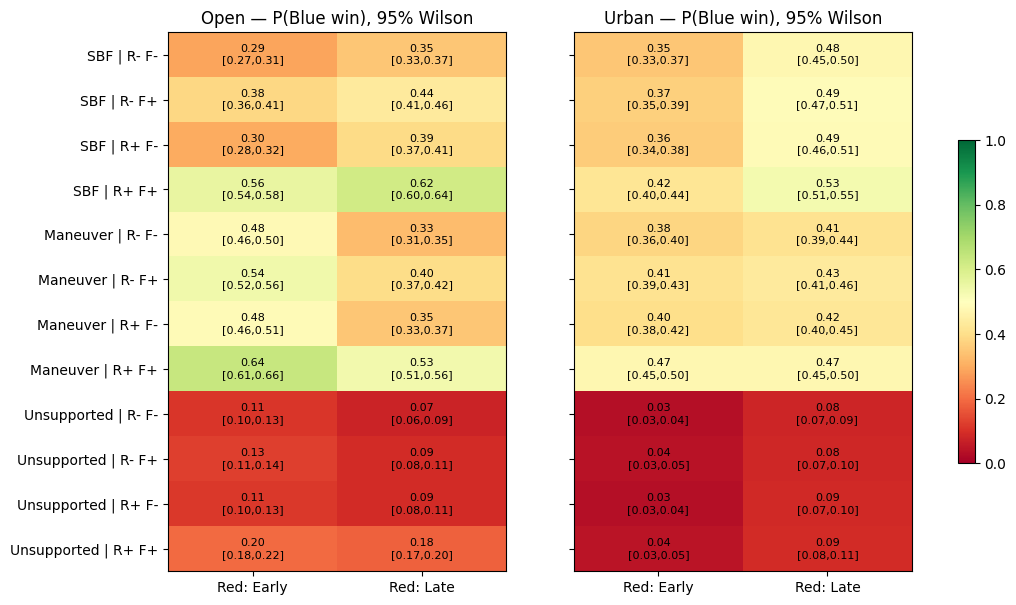

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharey=True)
labels = [blabel(*b) for b in BLUE_COAS]
for ax, terr in zip(axes, TERRAINS):
    M = np.array([[df.query("terrain==@terr and red==@rd and blue==@b").p_win.item() for rd in REDS] for b in labels])
    im = ax.imshow(M, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto")
    for i, b in enumerate(labels):
        for j, rd in enumerate(REDS):
            row = df.query("terrain==@terr and red==@rd and blue==@b").iloc[0]
            ax.text(j, i, f"{row.p_win:.2f}\n[{row.lo:.2f},{row.hi:.2f}]", ha="center", va="center", fontsize=8)
    ax.set_xticks(range(2), [f"Red: {r}" for r in REDS]); ax.set_title(f"{terr.title()} — P(Blue win), 95% Wilson")
axes[0].set_yticks(range(len(labels)), labels)
fig.colorbar(im, ax=axes, shrink=0.6); plt.show()

## 6. Game analysis: is the decision robust, not just the cells?
Treat each terrain as a zero-sum game with payoff $\hat\theta_{ij}=\hat P(\text{Blue win})$.

- **Pure maximin**: Blue picks the COA with the best worst-case payoff, $\max_i \min_j \hat\theta_{ij}$.
- **Mixed equilibrium**: solved by LP as $\max v$ subject to $x^\top \hat\Theta_{\cdot j} \ge v\ \forall j$, $\sum x = 1$, $x \ge 0$.

To test robustness, bootstrap the replications, resampling indices jointly so the CRN pairing is preserved. The output is how often each COA is the maximin choice, plus a percentile CI on the game value.

In [8]:
def solve_zero_sum(A):
    m, k = A.shape
    c = np.r_[np.zeros(m), -1.0]
    A_ub = np.c_[-A.T, np.ones(k)]
    res = linprog(c, A_ub=A_ub, b_ub=np.zeros(k), A_eq=np.r_[np.ones(m), 0][None], b_eq=[1],
                  bounds=[(0, 1)] * m + [(None, None)], method="highs")
    return res.x[:m], res.x[-1]

B_BOOT = 500
rng = np.random.default_rng(7)
for terr in TERRAINS:
    W = np.stack([[RES[terr, rd, *b]["win"] for rd in REDS] for b in BLUE_COAS])   # (12, 2, n)
    A = W.mean(-1)
    x, v = solve_zero_sum(A)
    mm = A.min(1).argmax()
    picks, vals = np.zeros(len(BLUE_COAS)), []
    for _ in range(B_BOOT):
        idx = rng.integers(0, N_REPS, N_REPS)
        Ab = W[:, :, idx].mean(-1)
        picks[Ab.min(1).argmax()] += 1
        vals.append(solve_zero_sum(Ab)[1])
    print(f"\n=== {terr.upper()} ===")
    print(f"Pure maximin: {labels[mm]}  (worst case {A[mm].min():.3f});  bootstrap selection freq:")
    for i in np.argsort(-picks)[:3]:
        if picks[i]: print(f"    {labels[i]:28s} {picks[i] / B_BOOT:.2f}")
    print(f"Mixed-strategy value {v:.3f}  95% boot CI [{np.percentile(vals, 2.5):.3f}, {np.percentile(vals, 97.5):.3f}]")
    print("  Blue mix:", {labels[i]: round(float(x[i]), 3) for i in np.flatnonzero(x > 1e-3)})


=== OPEN ===
Pure maximin: SBF | R+ F+  (worst case 0.558);  bootstrap selection freq:
    SBF | R+ F+                  0.92
    Maneuver | R+ F+             0.08
Mixed-strategy value 0.586  95% boot CI [0.573, 0.599]
  Blue mix: {'SBF | R+ F+': 0.632, 'Maneuver | R+ F+': 0.368}



=== URBAN ===
Pure maximin: Maneuver | R+ F+  (worst case 0.473);  bootstrap selection freq:
    Maneuver | R+ F+             1.00
Mixed-strategy value 0.473  95% boot CI [0.451, 0.487]
  Blue mix: {'Maneuver | R+ F+': 1.0}


## 7. Combined-arms synergy: recon × fires interaction
The recon × fires interaction for replication $k$ is the second difference
$I_k = Y^{++}_k - Y^{+-}_k - Y^{-+}_k + Y^{--}_k$.
All four terms come from the same seed, so their correlation is kept and $\mathrm{SE}=s_I/\sqrt n$. Intervals are Bonferroni-adjusted across the 12 contrasts. A positive $I$ means the two capabilities are worth more together than the sum of their separate effects.

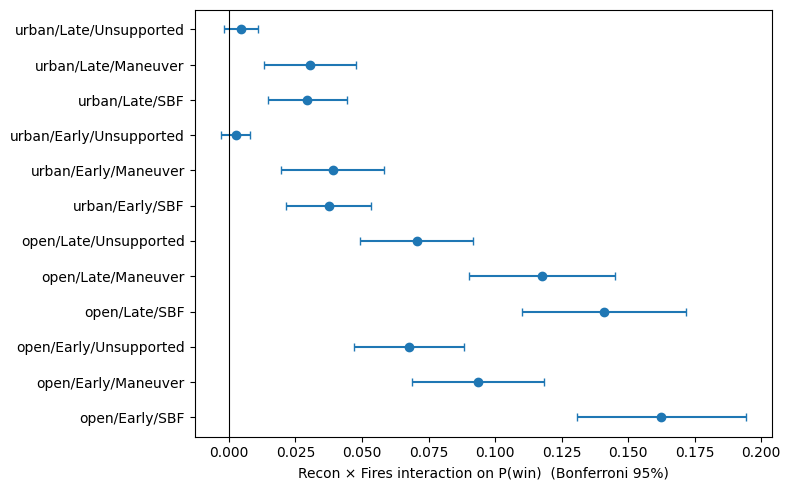

,terrain,red,armor,interaction,lo,hi
0,open,Early,SBF,0.162,0.131,0.194
1,open,Early,Maneuver,0.094,0.069,0.118
2,open,Early,Unsupported,0.068,0.047,0.088
3,open,Late,SBF,0.141,0.110,0.172
4,open,Late,Maneuver,0.118,0.090,0.145
5,open,Late,Unsupported,0.070,0.049,0.092
6,urban,Early,SBF,0.038,0.022,0.053
7,urban,Early,Maneuver,0.039,0.020,0.058
8,urban,Early,Unsupported,0.002,-0.003,0.008
9,urban,Late,SBF,0.030,0.015,0.044


In [9]:
K = len(TERRAINS) * len(REDS) * 3
zb = norm.ppf(1 - 0.05 / (2 * K))
syn = []
for terr in TERRAINS:
    for rd in REDS:
        for a in ["SBF", "Maneuver", "Unsupported"]:
            y = {(rc, fi): RES[terr, rd, a, rc, fi]["win"] for rc in (0, 1) for fi in (0, 1)}
            I = y[1, 1] - y[1, 0] - y[0, 1] + y[0, 0]
            se = I.std(ddof=1) / np.sqrt(len(I))
            syn.append(dict(terrain=terr, red=rd, armor=a, interaction=I.mean(), lo=I.mean() - zb * se, hi=I.mean() + zb * se))
syn = pd.DataFrame(syn)
fig, ax = plt.subplots(figsize=(8, 5))
yl = [f"{r.terrain}/{r.red}/{r.armor}" for r in syn.itertuples()]
ax.errorbar(syn.interaction, range(len(syn)), xerr=[syn.interaction - syn.lo, syn.hi - syn.interaction], fmt="o", capsize=3)
ax.axvline(0, color="k", lw=0.8); ax.set_yticks(range(len(syn)), yl)
ax.set_xlabel("Recon × Fires interaction on P(win)  (Bonferroni 95%)"); plt.tight_layout(); plt.show()
syn.round(3)

## 8. Does urban terrain make infantry necessary?
The infantry effect in a given cell is the paired contrast $\Delta = P(\text{Maneuver}) - P(\text{Unsupported})$.

The hypothesis is a difference-in-differences: $\Delta_{\text{urban}} > \Delta_{\text{open}}$. The two terrains use independent seeds, so the variances add.

In [10]:
out = []
for rd in REDS:
    for rc in (False, True):
        for fi in (False, True):
            est = {}
            for terr in TERRAINS:
                d = RES[terr, rd, "Maneuver", rc, fi]["win"] - RES[terr, rd, "Unsupported", rc, fi]["win"]
                est[terr] = (d.mean(), d.var(ddof=1) / len(d))
            did = est["urban"][0] - est["open"][0]; se = np.sqrt(est["urban"][1] + est["open"][1])
            out.append(dict(red=rd, blue=f"R{'+' if rc else '-'} F{'+' if fi else '-'}",
                            inf_effect_open=est["open"][0], inf_effect_urban=est["urban"][0],
                            DiD=did, DiD_lo=did - 1.96 * se, DiD_hi=did + 1.96 * se))
pd.DataFrame(out).round(3)

,red,blue,inf_effect_open,inf_effect_urban,DiD,DiD_lo,DiD_hi
0,Early,R- F-,0.370,0.347,-0.024,-0.054,0.007
1,Early,R- F+,0.412,0.373,-0.039,-0.070,-0.008
2,Early,R+ F-,0.370,0.368,-0.002,-0.033,0.029
3,Early,R+ F+,0.438,0.430,-0.007,-0.039,0.025
4,Late,R- F-,0.257,0.334,0.077,0.046,0.107
5,Late,R- F+,0.302,0.352,0.049,0.018,0.080
6,Late,R+ F-,0.260,0.338,0.078,0.048,0.108
7,Late,R+ F+,0.352,0.382,0.030,-0.003,0.062


## 9. Input uncertainty: the error the CIs above don't show
The parameters are guesses, so here they are drawn from priors in an outer loop ($M$ draws), with the simulation run in an inner loop for each draw. The variance of the inner estimates splits into two parts:
$\mathrm{Var}(\hat p_m) = \mathrm{Var}_\theta(p(\theta)) + E_\theta\!\left[p(1-p)/n\right]$.
Compare the resulting spread of $p(\theta)$ with the Monte Carlo-only interval from Section 5.

MC-only 95% CI at nominal params: [0.536, 0.580]  (half-width 0.022)
Across parameter draws: mean 0.515, 2.5–97.5% range [0.328, 0.721]
Share of variance from parameters: 96%


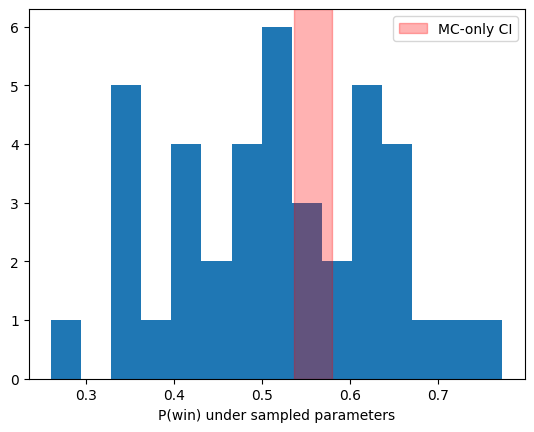

In [11]:
M, n_in = 40, 400
cell = ("open", "Early", "SBF", True, True)
rng = np.random.default_rng(11)
ph = []
for m in range(M):
    P = default_params()
    ln = lambda s: np.exp(rng.normal(0, s))
    P["PK"][[R_AT, R_INF]] = np.minimum(P["PK"][[R_AT, R_INF]] * ln(0.2), 0.95)
    P["PK"][:R_AT] = np.minimum(P["PK"][:R_AT] * ln(0.2), 0.95)
    P["theta0"] = P["theta0"] * ln(0.2)
    P["lam_blue"] *= ln(0.3); P["lam_red"] *= ln(0.3); P["k_det"] *= ln(0.3)
    terr, rd, a, rc, fi = cell
    ph.append(simulate(terr, a, rc, fi, rd, n_in, seed=[5, m], P=P)["win"].mean())
ph = np.array(ph)
var_total = ph.var(ddof=1)
var_mc = np.mean(ph * (1 - ph) / (n_in - 1))
var_param = max(var_total - var_mc, 0)
lo, hi = wilson(RES[cell[0], cell[1], *cell[2:]]["win"].sum(), N_REPS)
print(f"MC-only 95% CI at nominal params: [{lo:.3f}, {hi:.3f}]  (half-width {(hi - lo) / 2:.3f})")
print(f"Across parameter draws: mean {ph.mean():.3f}, 2.5–97.5% range [{np.percentile(ph, 2.5):.3f}, {np.percentile(ph, 97.5):.3f}]")
print(f"Share of variance from parameters: {var_param / var_total:.0%}")
plt.hist(ph, bins=15); plt.axvspan(lo, hi, alpha=0.3, color="r", label="MC-only CI")
plt.xlabel("P(win) under sampled parameters"); plt.legend(); plt.show()

## 10. Extensions
- **Calibration**: fit the choice-model β's and λ by conditional-logit MLE on instrumented engagement data, and replace the lognormal priors with posteriors.
- **Sensitivity**: use a nearly orthogonal Latin hypercube over the parameters, fit a GP metamodel, and compute Sobol indices.
- **Mechanics**: smoke, obstacles, Red counter-battery, IFVs staying in the fight after dismount, a 2D terrain grid with ray-cast LOS, and a nested logit to remove IIA for clustered targets.
- **Campaigns**: chain engagements with repair, resupply, and adaptive policies.

### Saving to GitHub from Colab
`File → Save a copy in GitHub`, then authorize and pick the repo and branch. Once it's saved, replace `USER/REPO` in the badge at the top.